# Qwen3-VL-2B vs TrOCR Elastic Augmentation — READ Dataset

Zero-shot evaluation of **Qwen3-VL-2B-Instruct** on the READ ICFHR 2016 test set,  
compared against our fine-tuned **TrOCR Elastic Aug** checkpoint (`best_read_elastic/`).

| Model | Training | Dataset |
|---|---|---|
| TrOCR Elastic Aug | Fine-tuned (Base → READ) | READ train set |
| Qwen3-VL-2B-Instruct | Zero-shot | — |

> **Note:** This notebook installs `transformers` from git (Qwen3-VL needs ≥4.57.0, not yet on PyPI).  
> Run the install cell once; afterwards restart the kernel and skip it.
>
> API: `processor.apply_chat_template(..., return_dict=True)` übernimmt alles inkl. Bildvorverarbeitung —  
> kein `qwen-vl-utils` / `process_vision_info` notwendig.

## Step 0 — Install Dependencies

**Run once, then restart the kernel.**  
Qwen3-VL requires `transformers>=4.57.0` which is not yet on PyPI.

In [ ]:
# Dependencies are pinned in requirements.txt — install once from repo root:
#   pip install -r requirements.txt

## Step 1 — Imports & Paths

In [ ]:
import os
import json
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT     = Path("..")
READ_DIR = ROOT / "data" / "READDataset"
CKPT_DIR = ROOT / "checkpoints" / "best_read_elastic"

QWEN_PREDS_PATH = ROOT / "checkpoints" / "qwen3vl_read_predictions.json"

# Dynamic resolution: controls how many 28×28 patches Qwen allocates
MIN_PIXELS = 256  * 28 * 28
MAX_PIXELS = 1280 * 28 * 28

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"READ   : {READ_DIR.resolve()}")

import transformers
print(f"transformers version: {transformers.__version__}")

## Step 2 — Load READ Test Set

In [2]:
PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES = {"paragraph", "heading"}


def parse_page_xml(xml_path: Path, image_path: Path) -> list:
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({
                    "image_path":    str(image_path),
                    "bbox":          bbox,
                    "transcription": u.text.strip(),
                })
    return records


test_xml_dir = READ_DIR / "Test-ICFHR-2016" / "page"
test_img_dir = READ_DIR / "Test-ICFHR-2016"

records = []
for xml_file in sorted(test_xml_dir.glob("*.xml")):
    img_file = test_img_dir / (xml_file.stem + ".JPG")
    if img_file.exists():
        records.extend(parse_page_xml(xml_file, img_file))

df_test = pd.DataFrame(records)
print(f"READ test lines : {len(df_test)}")
df_test.head(5)

READ test lines : 1138


,image_path,bbox,transcription
0,../data/READDataset/Test-ICFHR-2016/Seite0405.JPG,"(1632, 267, 1858, 335)",203
1,../data/READDataset/Test-ICFHR-2016/Seite0405.JPG,"(700, 500, 1755, 597)",schafft. Aūch das Er der
2,../data/READDataset/Test-ICFHR-2016/Seite0405.JPG,"(722, 590, 1799, 712)",Leibaigenschafft freÿ seie.
3,../data/READDataset/Test-ICFHR-2016/Seite0405.JPG,"(721, 711, 1752, 819)",ists gegen. 6 fl Tax ver¬
4,../data/READDataset/Test-ICFHR-2016/Seite0405.JPG,"(716, 825, 1105, 900)",willigt.


## Step 3 — Load Qwen3-VL-2B-Instruct

The 2B model fits in ~4 GB VRAM (`dtype="auto"` wählt fp16 auf GPU).  
`apply_chat_template` übernimmt die komplette Bildvorverarbeitung — kein extra Paket nötig.  
`do_sample=False` (greedy) für reproduzierbare, deterministische Ausgabe.

In [ ]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# min_pixels / max_pixels steuern die dynamische Auflösung der Patches
qwen_processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS,
)
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
).to(device)
qwen_model.eval()

print(f"Loaded  : {MODEL_ID}")
print(f"Device  : {next(qwen_model.parameters()).device}")
print(f"Params  : {sum(p.numel() for p in qwen_model.parameters()) / 1e9:.1f}B")
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f"VRAM    : {allocated:.1f} GB used")

## Step 4 — Inference Helper

In [ ]:
PROMPT = (
    "You are transcribing a document from the Ratsprotokolle collection — "
    "minutes of council meetings held in Bolzano from 1470 to 1805. "
    "Language: Early Modern German. Script: historical German cursive. "
    "Multiple authors, exact number unknown. "
    "Transcribe the handwritten text in this image exactly as it appears, "
    "preserving all special characters, abbreviations, and diacritics. "
    "Output only the transcription — nothing else."
)

_page_cache: dict = {}


def crop_line(image_path: str, bbox: tuple) -> Image.Image:
    if image_path not in _page_cache:
        _page_cache[image_path] = Image.open(image_path).convert("RGB")
    return _page_cache[image_path].crop(bbox)


def pad_to_square(img: Image.Image, fill: int = 255) -> Image.Image:
    """Pad to square with white background — prevents internal aspect-ratio distortion."""
    w, h   = img.size
    size   = max(w, h)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    canvas.paste(img, ((size - w) // 2, (size - h) // 2))
    return canvas


def qwen_transcribe(pil_image: Image.Image) -> str:
    """Run Qwen3-VL on a single PIL image and return the transcription string."""
    img = pad_to_square(pil_image)
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": PROMPT},
        ],
    }]
    inputs = qwen_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
        )

    trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output = qwen_processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()
    return output


# Sanity check on one line
row_sample  = df_test.iloc[5]
crop_sample = crop_line(row_sample["image_path"], row_sample["bbox"])
pred_sample = qwen_transcribe(crop_sample)
print(f"GT  : {row_sample['transcription']}")
print(f"Pred: {pred_sample}")
crop_sample

## Step 5 — Run Qwen3-VL on Full Test Set

Predictions are saved to `checkpoints/qwen3vl_read_predictions.json` after each page  
so inference can be resumed if the kernel is interrupted.

In [8]:
# Resume from checkpoint if available — delete corrupted file and restart if parse fails
if QWEN_PREDS_PATH.exists():
    try:
        with open(QWEN_PREDS_PATH, encoding="utf-8") as f:
            qwen_preds = json.load(f)
        print(f"Loaded {len(qwen_preds)} existing predictions from {QWEN_PREDS_PATH}")
    except (json.JSONDecodeError, UnicodeDecodeError) as e:
        print(f"Checkpoint file corrupted ({e}) — deleting and starting from scratch.")
        QWEN_PREDS_PATH.unlink()
        qwen_preds = []
else:
    qwen_preds = []

start_idx = len(qwen_preds)
refs       = df_test["transcription"].tolist()

if start_idx < len(df_test):
    torch.cuda.empty_cache()
    for idx in tqdm(range(start_idx, len(df_test)), desc="Qwen3-VL inference"):
        row  = df_test.iloc[idx]
        crop = crop_line(row["image_path"], row["bbox"])
        pred = qwen_transcribe(crop)
        qwen_preds.append(pred)

        # Save every 50 lines as checkpoint
        if (idx + 1) % 50 == 0:
            with open(QWEN_PREDS_PATH, "w", encoding="utf-8") as f:
                json.dump(qwen_preds, f, ensure_ascii=False, indent=2)

    # Final save
    with open(QWEN_PREDS_PATH, "w", encoding="utf-8") as f:
        json.dump(qwen_preds, f, ensure_ascii=False, indent=2)
    print(f"Done. {len(qwen_preds)} predictions saved to {QWEN_PREDS_PATH}")
else:
    print("All predictions already computed — skipping inference.")

assert len(qwen_preds) == len(refs), f"Mismatch: {len(qwen_preds)} preds vs {len(refs)} refs"
print(f"Total predictions: {len(qwen_preds)}")

Checkpoint file corrupted (Expecting ',' delimiter: line 2 column 8 (char 9)) — deleting and starting from scratch.


Qwen3-VL inference:   0%|          | 0/1138 [00:00<?, ?it/s]

Done. 1138 predictions saved to ../checkpoints/qwen3vl_read_predictions.json
Total predictions: 1138


## Step 6 — Compute CER / WER for Qwen3-VL

In [9]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

qwen_cer = cer_metric.compute(predictions=qwen_preds, references=refs)
qwen_wer = wer_metric.compute(predictions=qwen_preds, references=refs)

print(f"Qwen3-VL-2B (zero-shot)")
print(f"  CER : {qwen_cer:.4f}  ({qwen_cer * 100:.2f}%)")
print(f"  WER : {qwen_wer:.4f}  ({qwen_wer * 100:.2f}%)")

Qwen3-VL-2B (zero-shot)
  CER : 1.6390  (163.90%)
  WER : 2.5104  (251.04%)


## Step 7 — Comparison Table

TrOCR Elastic Aug results are taken from `elastic_aug_READ.ipynb` (Step 7, same test set).

In [10]:
# TrOCR elastic aug results from elastic_aug_READ.ipynb — same 1138 test lines
TROCR_CER = 7.02
TROCR_WER = 28.69

df_results = pd.DataFrame([
    {
        "Modell":     "TrOCR Elastic Aug",
        "Typ":        "Fine-tuned (Base → READ)",
        "Checkpoint": "best_read_elastic/",
        "CER (%)": TROCR_CER,
        "WER (%)": TROCR_WER,
    },
    {
        "Modell":     "Qwen3-VL-2B-Instruct",
        "Typ":        "Zero-shot (kein Fine-tuning)",
        "Checkpoint": "Qwen/Qwen3-VL-2B-Instruct",
        "CER (%)": round(qwen_cer * 100, 2),
        "WER (%)": round(qwen_wer * 100, 2),
    },
]).set_index("Modell")

print("=" * 65)
print("READ Test Set (ICFHR 2016) — CER / WER Comparison")
print("=" * 65)
display(df_results)

# Delta
delta_cer = round(qwen_cer * 100 - TROCR_CER, 2)
delta_wer = round(qwen_wer * 100 - TROCR_WER, 2)
sign_cer  = "+" if delta_cer > 0 else ""
sign_wer  = "+" if delta_wer > 0 else ""
print(f"\nDelta (Qwen − TrOCR):  CER {sign_cer}{delta_cer:.2f}pp  |  WER {sign_wer}{delta_wer:.2f}pp")

READ Test Set (ICFHR 2016) — CER / WER Comparison


,Typ,Checkpoint,CER (%),WER (%)
Modell,,,,
TrOCR Elastic Aug,Fine-tuned (Base → READ),best_read_elastic/,7.02,28.69
Qwen3-VL-2B-Instruct,Zero-shot (kein Fine-tuning),Qwen/Qwen3-VL-2B-Instruct,163.90,251.04



Delta (Qwen − TrOCR):  CER +156.88pp  |  WER +222.35pp


## Step 8 — Visualisation

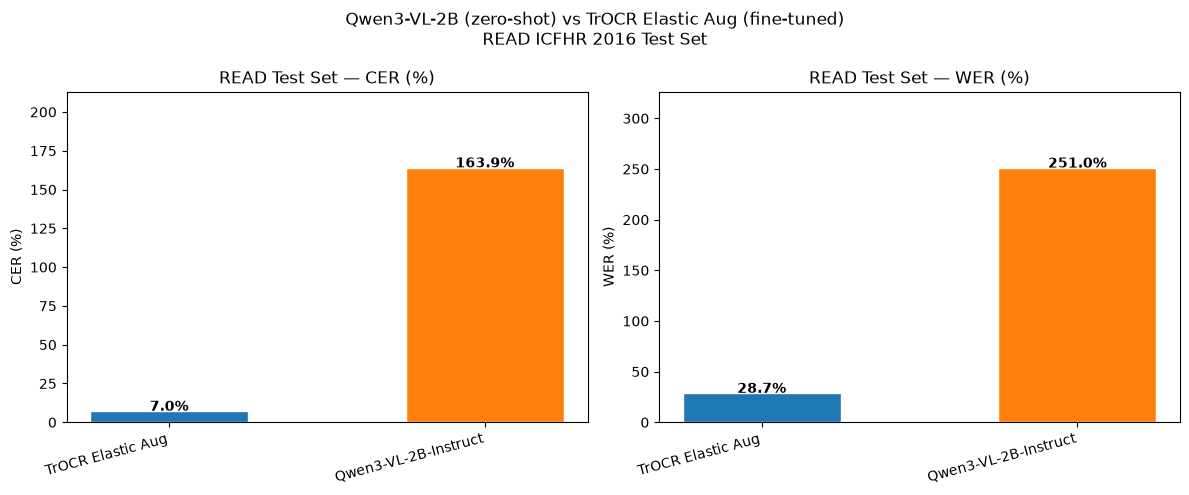

Saved to ../checkpoints/qwen3vl_vs_trocr_comparison.png


In [11]:
colors = ["#1f77b4", "#ff7f0e"]
labels = df_results.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ["CER (%)", "WER (%)"]):
    vals = df_results[metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_title(f"READ Test Set — {metric}", fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{val:.1f}%",
            ha="center", fontsize=10, fontweight="bold",
        )
    ax.set_ylim(0, max(vals) * 1.3)

plt.suptitle(
    "Qwen3-VL-2B (zero-shot) vs TrOCR Elastic Aug (fine-tuned)\n"
    "READ ICFHR 2016 Test Set",
    fontsize=12,
)
plt.tight_layout()

out_path = ROOT / "checkpoints" / "qwen3vl_vs_trocr_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")

## Step 9 — Qualitative Examples

10 random test lines with image crop and both model predictions side by side.

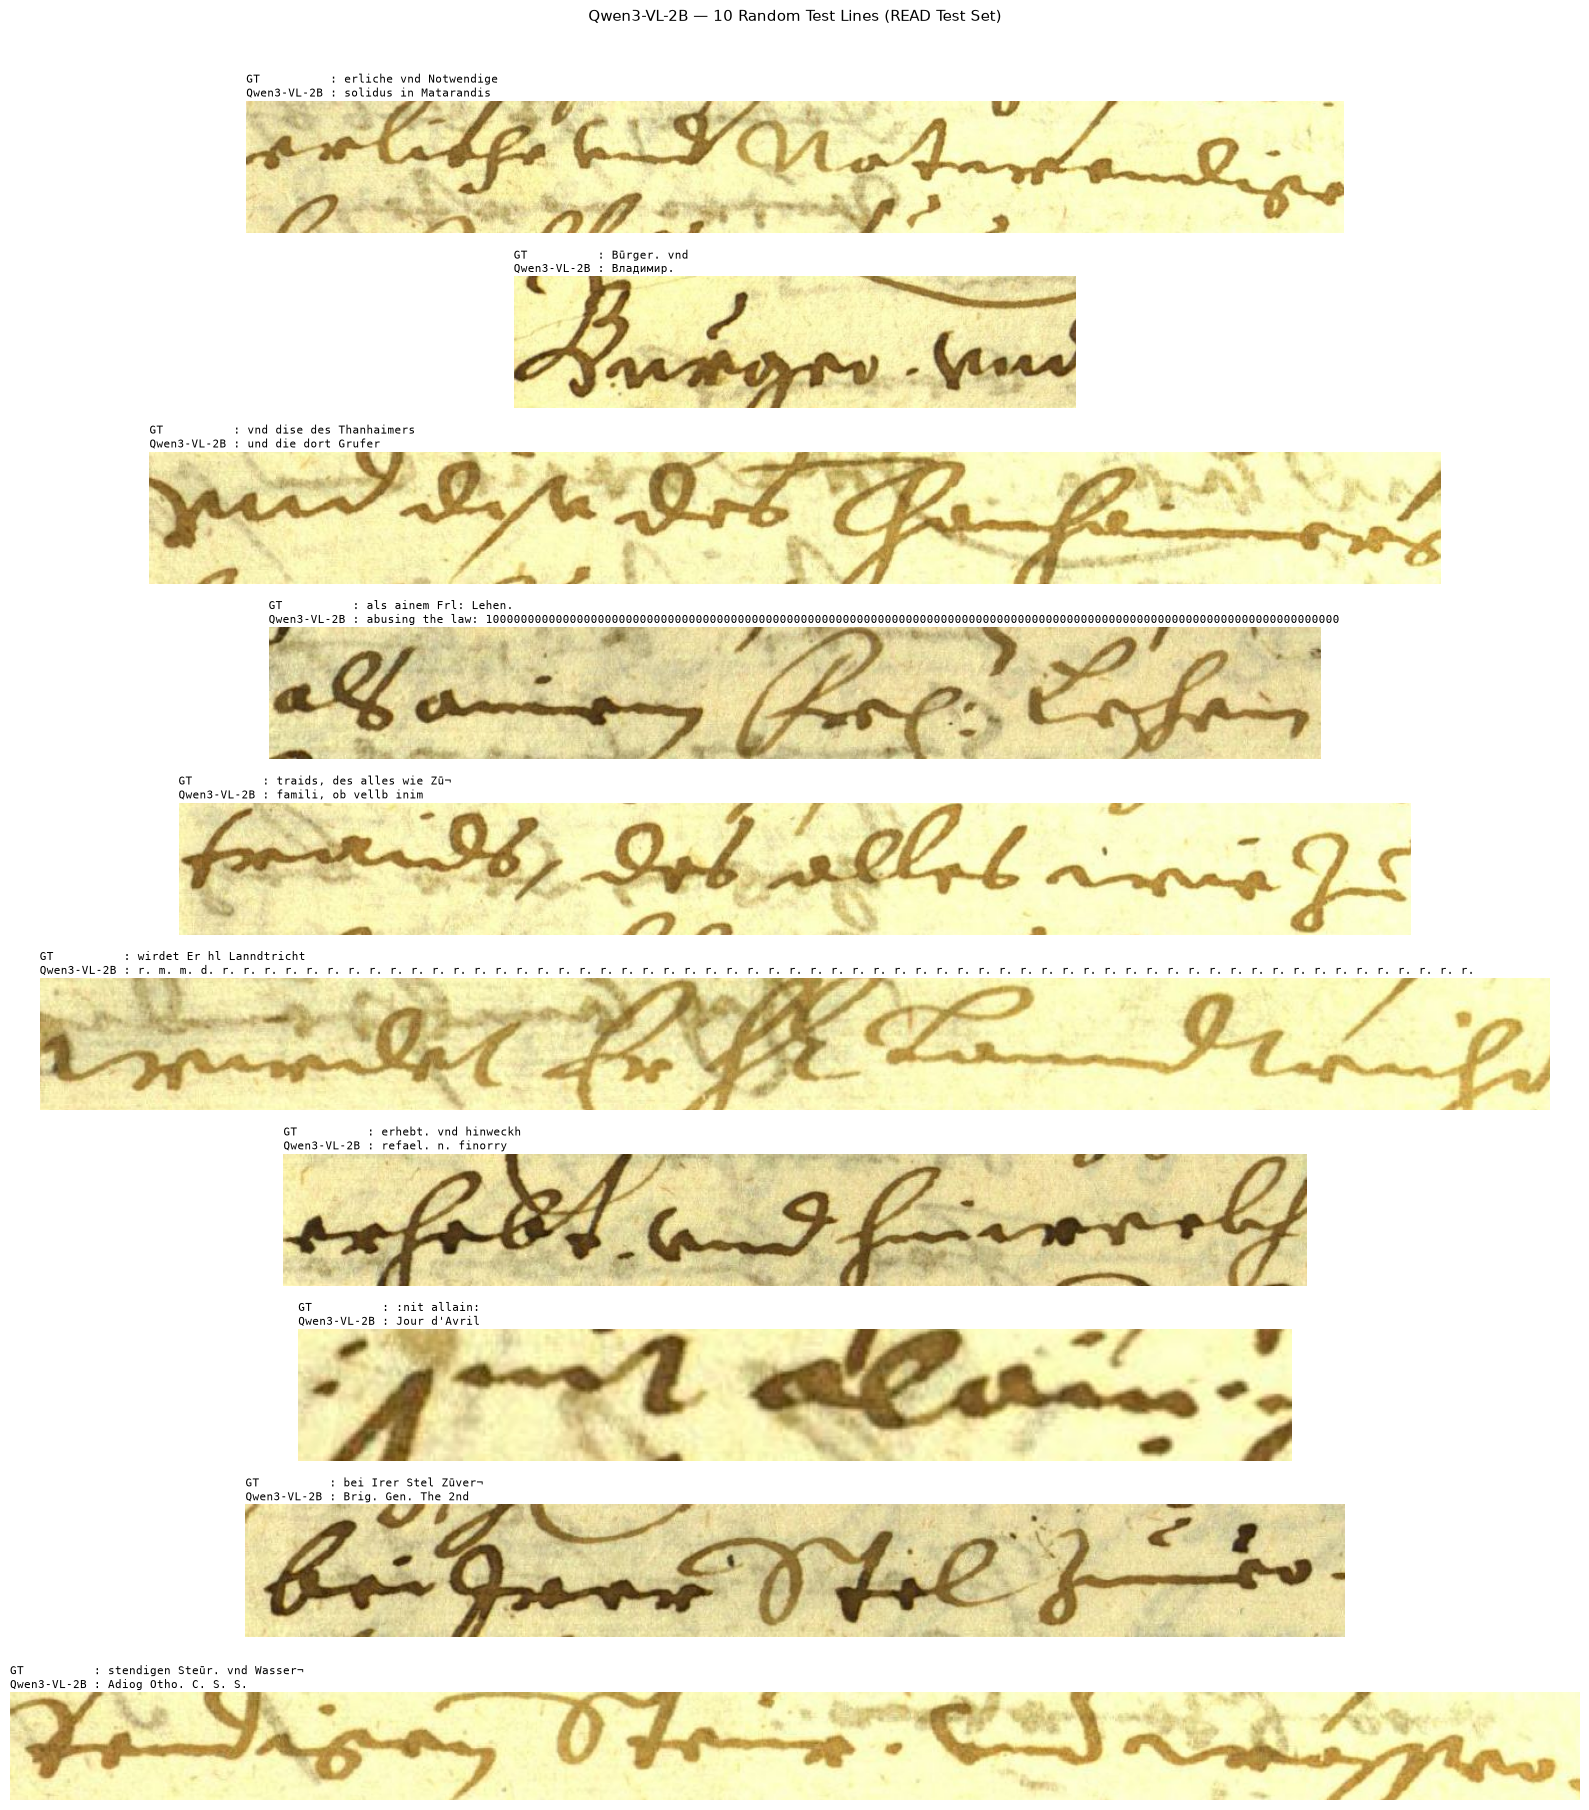

In [12]:
sample_idx = df_test.sample(10, random_state=SEED).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(16, 18))
for ax, idx in zip(axes, sample_idx):
    row  = df_test.iloc[idx]
    crop = crop_line(row["image_path"], row["bbox"])
    gt   = row["transcription"]
    pred = qwen_preds[idx]
    ax.imshow(crop)
    ax.set_title(
        f"GT          : {gt}\n"
        f"Qwen3-VL-2B : {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("Qwen3-VL-2B — 10 Random Test Lines (READ Test Set)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Step 10 — Worst Predictions (Highest per-line CER)

/tmp/ipykernel_32316/3627165955.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


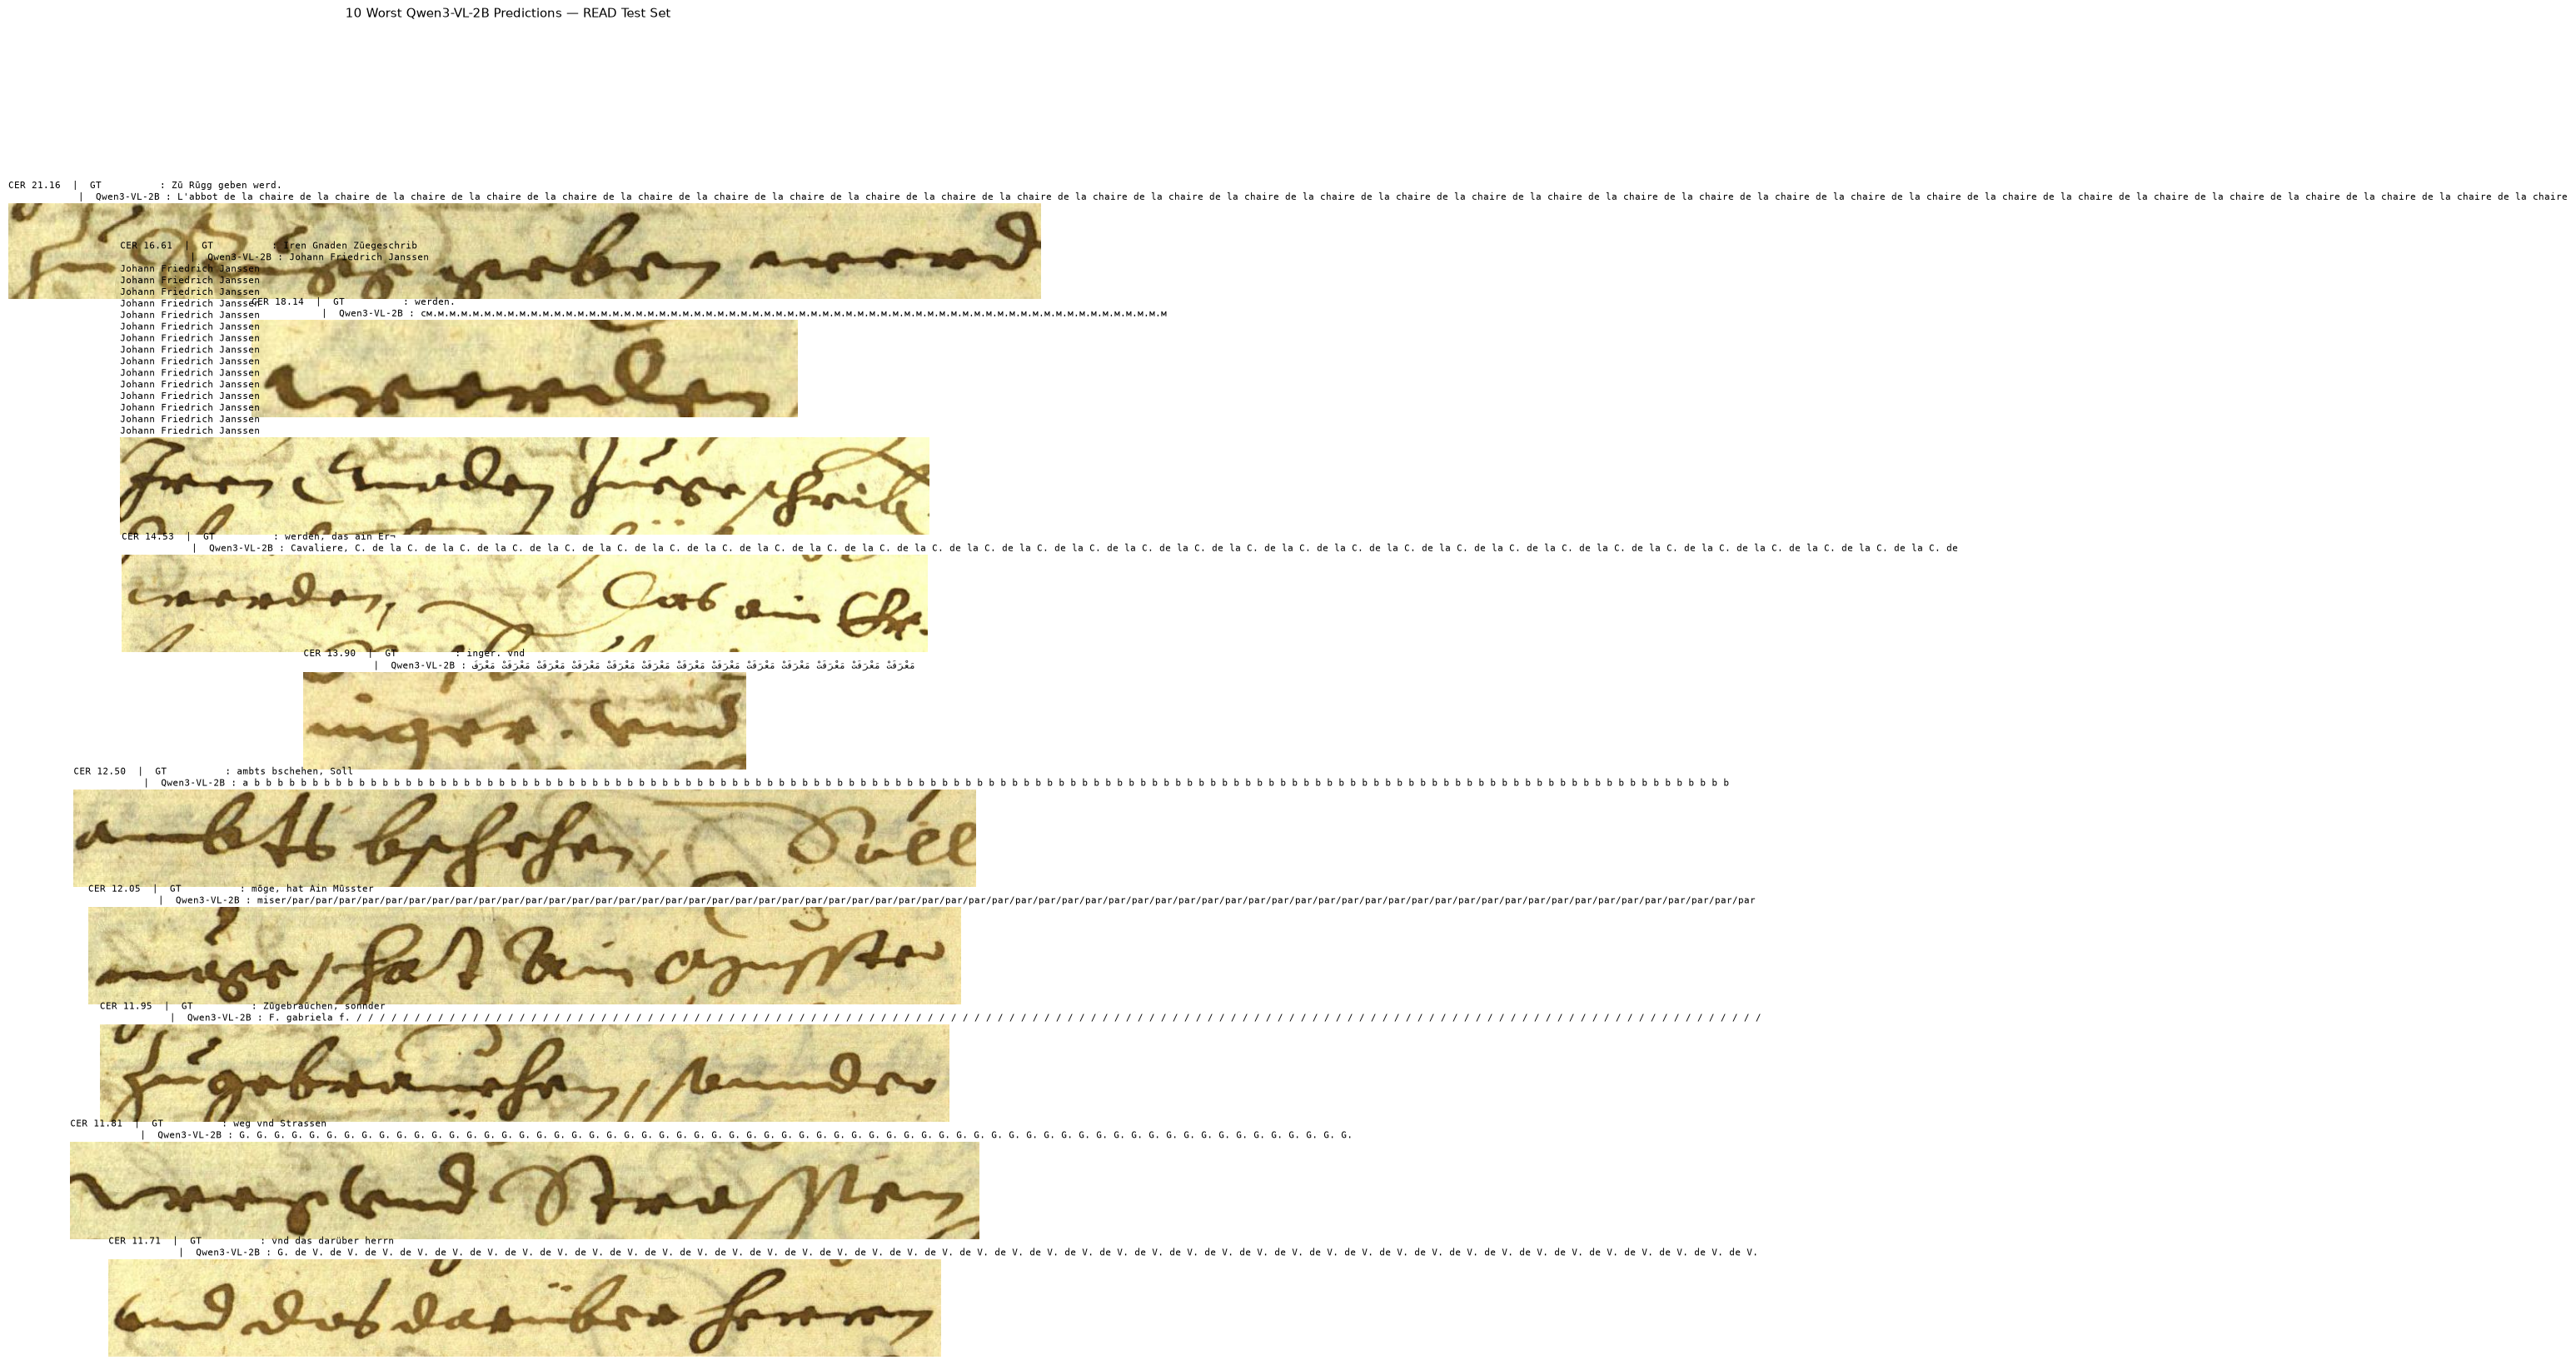

In [13]:
from jiwer import cer as line_cer

errors = sorted(
    [
        (line_cer(ref, pred), idx, ref, pred)
        for idx, (pred, ref) in enumerate(zip(qwen_preds, refs))
        if ref.strip()
    ],
    reverse=True,
)
worst = errors[:10]

fig, axes = plt.subplots(10, 1, figsize=(16, 18))
for ax, (c, idx, ref, pred) in zip(axes, worst):
    row  = df_test.iloc[idx]
    crop = crop_line(row["image_path"], row["bbox"])
    ax.imshow(crop)
    ax.set_title(
        f"CER {c:.2f}  |  GT          : {ref}\n"
        f"            |  Qwen3-VL-2B : {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Qwen3-VL-2B Predictions — READ Test Set", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "checkpoints" / "qwen3vl_worst_predictions.png", dpi=150, bbox_inches="tight")
plt.show()